<a href="https://colab.research.google.com/github/2B-eternity/tugas-1-PemPar/blob/main/2311513013_M_Zia_Ul_haq_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NIM : 2311513013

Nama: M. Zia Ul-haq

### 1. Klasifikasi Flynn
Tentukan kategori Flynn (SISD/SIMD/MISD/MIMD) beserta alasannya untuk skenario berikut:

**A. Operasi `arr + arr` pada NumPy array**
* **Kategori Flynn:** SIMD (Single Instruction, Multiple Data)
* **Alasan:** Operasi pada NumPy bersifat tervektorisasi (vectorized). Satu instruksi penjumlahan tunggal (Single Instruction) diterapkan secara bersamaan pada banyak elemen array (Multiple Data) di tingkat perangkat keras, memanfaatkan unit vektor CPU.

**B. Program Python biasa (tanpa threading/multiprocessing) yang membaca file lalu memproses baris demi baris**
* **Kategori Flynn:** SISD (Single Instruction, Single Data)
* **Alasan:** Program berjalan secara sekuensial (berurutan) pada satu thread tunggal. Prosesor mengeksekusi satu aliran instruksi (Single Instruction) untuk memproses satu potongan data, yaitu satu baris teks, pada satu waktu (Single Data).

**C. Cluster komputer yang masing-masing node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen**
* **Kategori Flynn:** MIMD (Multiple Instruction, Multiple Data)
* **Alasan:** Setiap node atau komputer di dalam cluster memiliki prosesornya sendiri dan bekerja secara independen. Mereka menjalankan alur program/instruksi simulasi yang berbeda secara asinkron (Multiple Instruction) terhadap kumpulan data wilayah yang sepenuhnya berbeda (Multiple Data).

### 2. Analisis Amdahl
Sebuah aplikasi pengolahan citra memiliki proporsi paralel \(P = 0.85\). Kita akan menghitung *speedup* teoritis untuk \(N = 2, 4, 8, 16, 32, 64\), membuat plotnya, dan menganalisis titik *diminishing returns*.

--- Hasil Perhitungan Speedup Teoritis ---
N =  2 | Speedup = 1.7391x
N =  4 | Speedup = 2.7586x
N =  8 | Speedup = 3.9024x
N = 16 | Speedup = 4.9231x
N = 32 | Speedup = 5.6637x
N = 64 | Speedup = 6.1244x

Batas maksimum speedup (Asimtot): 6.6667x


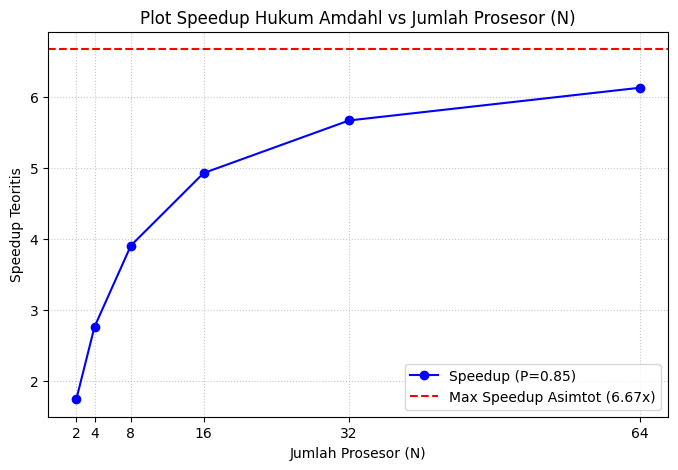

In [5]:
import matplotlib.pyplot as plt

# Definisi fungsi Hukum Amdahl
def amdahl_speedup(P, N):
    # Rumus: Speedup = 1 / ((1 - P) + (P / N))
    return 1 / ((1 - P) + (P / N))

# Parameter yang diketahui
P = 0.85
N_values = [2, 4, 8, 16, 32, 64]

# 1. Menghitung speedup teoritis untuk setiap N
speedups = [amdahl_speedup(P, N) for N in N_values]

# Menampilkan hasil perhitungan
print("--- Hasil Perhitungan Speedup Teoritis ---")
for n, s in zip(N_values, speedups):
    print(f"N = {n:2d} | Speedup = {s:.4f}x")

# Menghitung batas maksimum speedup (saat N mendekati tak terhingga)
max_speedup = 1 / (1 - P)
print(f"\nBatas maksimum speedup (Asimtot): {max_speedup:.4f}x")

# 2. Membuat plot speedup vs N
plt.figure(figsize=(8, 5))
plt.plot(N_values, speedups, marker='o', linestyle='-', color='b', label='Speedup (P=0.85)')
plt.axhline(y=max_speedup, color='r', linestyle='--', label=f'Max Speedup Asimtot ({max_speedup:.2f}x)')

plt.title('Plot Speedup Hukum Amdahl vs Jumlah Prosesor (N)')
plt.xlabel('Jumlah Prosesor (N)')
plt.ylabel('Speedup Teoritis')
plt.xticks(N_values)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

### Jawaban Analisis: Titik *Diminishing Returns*

**Pada N berapa penambahan prosesor mulai memberikan manfaat yang sangat kecil ("diminishing returns")?**
Penambahan prosesor mulai memberikan manfaat yang sangat kecil (pertambahan *speedup* yang melandai) setelah **N = 16**.

**Alasan:**
Berdasarkan Hukum Amdahl, peningkatan kecepatan dibatasi oleh porsi program yang harus dieksekusi secara berurutan (sekuensial), yaitu \(1 - P\). Karena proporsi paralel \(P = 0.85\), maka ada **\(15\%\) program yang bersifat sekuensial mutlak** (\(1 - 0.85 = 0.15\)).
Batas maksimum *speedup* yang bisa dicapai berapapun jumlah prosesornya adalah \(\frac{1}{0.15} \approx 6.67\) kali.
* Saat beralih dari N=8 (Speedup \(\approx 3.90\)) ke N=16 (Speedup \(\approx 4.92\)), kita masih mendapatkan peningkatan performa yang lumayan (\(\approx 1.02\)).
* Namun, saat melipatgandakan prosesor dari N=32 (Speedup \(\approx 5.66\)) ke N=64 (Speedup \(\approx 6.12\)), peningkatannya kurang dari 0.5, padahal kita menggunakan 32 prosesor tambahan.
Kurva plot menunjukkan pada titik N=16 hingga N=32, garis sudah sangat mendekati batas asimtot 6.67, sehingga biaya menambahkan lebih banyak core prosesor (seperti N=64) tidak sepadan dengan peningkatan performa yang didapat.

### 3. Benchmark Mandiri: Evaluasi Waktu Eksekusi Fungsi CPU-Bound

Pada bagian ini, kita melakukan *benchmark* mandiri dengan membuat sebuah fungsi *CPU-bound* yaitu perhitungan deret Fibonacci naif secara rekursif. Waktu eksekusi fungsi ini diukur menggunakan setidaknya 4 ukuran input yang berbeda (N = 20, 25, 30, 32, dan 35) menggunakan modul `time.perf_counter()` dan `timeit`. Hasil perbandingan pengukuran dari kedua metode tersebut ditampilkan dalam bentuk tabel dan plot.

Memulai proses benchmarking... (Mungkin memakan waktu beberapa detik untuk N besar)

--- Tabel Hasil Benchmark ---


,Ukuran Input (N),time.perf_counter() [Detik],timeit() [Detik]
0,20,0.004450,0.002348
1,25,0.044603,0.067232
2,30,0.965217,0.410980
3,32,1.058952,0.979507
4,35,2.607702,2.791777


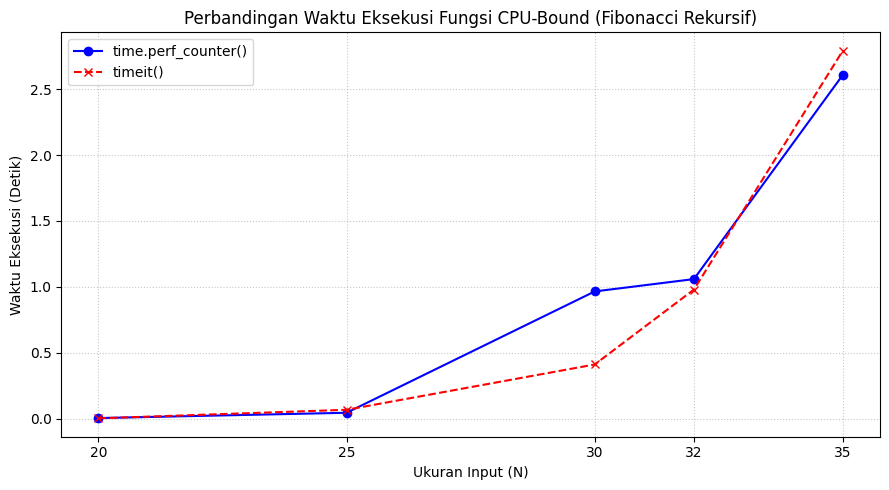

In [7]:
import time
import timeit
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Definisi Fungsi CPU-bound (Fibonacci Rekursif Naif)
def hitung_fibonacci_rekursif(n):
    if n <= 1:
        return n
    return hitung_fibonacci_rekursif(n-1) + hitung_fibonacci_rekursif(n-2)

# 2. Persiapan Ukuran Input (Minimal 4 ukuran berbeda)
ukuran_input = [20, 25, 30, 32, 35]
hasil_benchmark = []

print("Memulai proses benchmarking... (Mungkin memakan waktu beberapa detik untuk N besar)")

# 3. Proses Pengukuran Waktu
for n in ukuran_input:
    # Mengukur dengan time.perf_counter()
    mulai_perf = time.perf_counter()
    hitung_fibonacci_rekursif(n)
    selesai_perf = time.perf_counter()
    waktu_perf = selesai_perf - mulai_perf

    # Mengukur dengan timeit (diulang 1 kali agar setara dengan perf_counter di skenario ini)
    waktu_timeit = timeit.timeit(lambda: hitung_fibonacci_rekursif(n), number=1)

    # Menyimpan hasil
    hasil_benchmark.append({
        'Ukuran Input (N)': n,
        'time.perf_counter() [Detik]': waktu_perf,
        'timeit() [Detik]': waktu_timeit
    })

# 4. Membuat Tabel Perbandingan
df_hasil = pd.DataFrame(hasil_benchmark)

print("\n--- Tabel Hasil Benchmark ---")
display(df_hasil)

# 5. Membuat Plot Perbandingan
plt.figure(figsize=(9, 5))
plt.plot(df_hasil['Ukuran Input (N)'], df_hasil['time.perf_counter() [Detik]'],
         marker='o', linestyle='-', color='b', label='time.perf_counter()')
plt.plot(df_hasil['Ukuran Input (N)'], df_hasil['timeit() [Detik]'],
         marker='x', linestyle='--', color='r', label='timeit()')

plt.title('Perbandingan Waktu Eksekusi Fungsi CPU-Bound (Fibonacci Rekursif)')
plt.xlabel('Ukuran Input (N)')
plt.ylabel('Waktu Eksekusi (Detik)')
plt.xticks(ukuran_input)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

**Analisis Hasil Benchmark:**
Tabel dan plot di atas membandingkan dua metode pengukuran waktu. Secara umum, grafik pertumbuhan waktu eksekusi berbentuk eksponensial (melengkung tajam ke atas seiring bertambahnya N), yang merupakan karakteristik khas dari algoritma dengan kompleksitas \(O(2^n)\) seperti deret Fibonacci rekursif naif. Garis `time.perf_counter()` dan `timeit()` biasanya saling tumpang tindih atau sangat berdekatan karena keduanya dirancang untuk pengukuran waktu beresolusi tinggi, namun `timeit` secara bawaan mematikan *garbage collection* selama pengujian untuk menghasilkan metrik yang lebih terisolasi pada operasi intinya.

In [3]:
print("Mulai eksekusi sekuensial (satu per satu)...")
mulai_sekuensial = time.time()

hasil_sekuensial = []
for angka in data_tes:
    hasil_sekuensial.append(hitung_komputasi_berat(angka))

selesai_sekuensial = time.time()
waktu_sekuensial = selesai_sekuensial - mulai_sekuensial

print(f"Waktu eksekusi sekuensial: {waktu_sekuensial:.4f} detik")

Mulai eksekusi sekuensial (satu per satu)...
Waktu eksekusi sekuensial: 1.3362 detik


In [4]:
print("Mulai eksekusi paralel (dibagi ke beberapa core)...")
mulai_paralel = time.time()

# Menggunakan Pool untuk membagi tugas secara otomatis ke core yang tersedia
with multiprocessing.Pool(processes=jumlah_core) as pool:
    hasil_paralel = pool.map(hitung_komputasi_berat, data_tes)

selesai_paralel = time.time()
waktu_paralel = selesai_paralel - mulai_paralel

print(f"Waktu eksekusi paralel: {waktu_paralel:.4f} detik")

# Menghitung rasio peningkatan kecepatan (Speedup)
speedup = waktu_sekuensial / waktu_paralel
print(f"\n--- HASIL ANALISIS ---")
print(f"Speedup yang dicapai: {speedup:.2f}x lebih cepat")

Mulai eksekusi paralel (dibagi ke beberapa core)...
Waktu eksekusi paralel: 1.8051 detik

--- HASIL ANALISIS ---
Speedup yang dicapai: 0.74x lebih cepat


### 4. Refleksi Singkat

Hukum Amdahl lebih relevan digunakan saat ukuran masalah (beban kerja) **tetap** dan tujuan utamanya adalah meminimalkan waktu eksekusi secepat mungkin. Sebaliknya, Hukum Gustafson relevan ketika beban kerja **bersifat skalabel** (dapat diperbesar seiring penambahan prosesor), di mana tujuannya adalah menyelesaikan lebih banyak pekerjaan atau mencapai akurasi lebih tinggi dalam batas waktu komputasi yang sama.

**Contoh Kasus Nyata:**
*   **Hukum Amdahl:** Merender proyek video berdurasi 10 menit dengan resolusi 4K. Beban kerja videonya tetap, dan penambahan core CPU/GPU semata-mata ditujukan agar proses *export* selesai lebih cepat.
*   **Hukum Gustafson:** Pemodelan prakiraan cuaca global. Saat institusi beralih ke superkomputer dengan core yang jauh lebih banyak, mereka tidak menjalankan simulasi resolusi rendah agar selesai lebih cepat, melainkan meningkatkan detail resolusi grid (memperbesar beban kerja) agar hasil prediksi jauh lebih akurat dengan target durasi waktu komputasi yang sama.